In [126]:
import pandas as pd

In [127]:
df = pd.read_csv('../data/인구현황.csv')
df = df.loc[df['행정기관'] != '전국']
df.columns

Index(['행정기관코드', '행정기관', '총인구수', '세대수', '세대당 인구', '남자 인구수', '여자 인구수', '남여 비율'], dtype='object')

1. 지역별 총 인구수 TOP 5

In [128]:
df.loc[:,['행정기관', '총인구수']].sort_values('총인구수', ascending=False).head(5)


,행정기관,총인구수
9,경기도,13694685
1,서울특별시,9331828
2,부산광역시,3266598
16,경상남도,3228380
4,인천광역시,3021010


In [129]:
order = df.sort_values('총인구수', ascending=False)['행정기관']

In [130]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm   
import seaborn as sns

[(font.name, font.fname) for font in fm.fontManager.ttflist if 'Mal' in font.name]
font_path = 'C:\\Windows\\Fonts\\malgun.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc('font', family=font_name)

1-1. 지역별 총인구수 plot

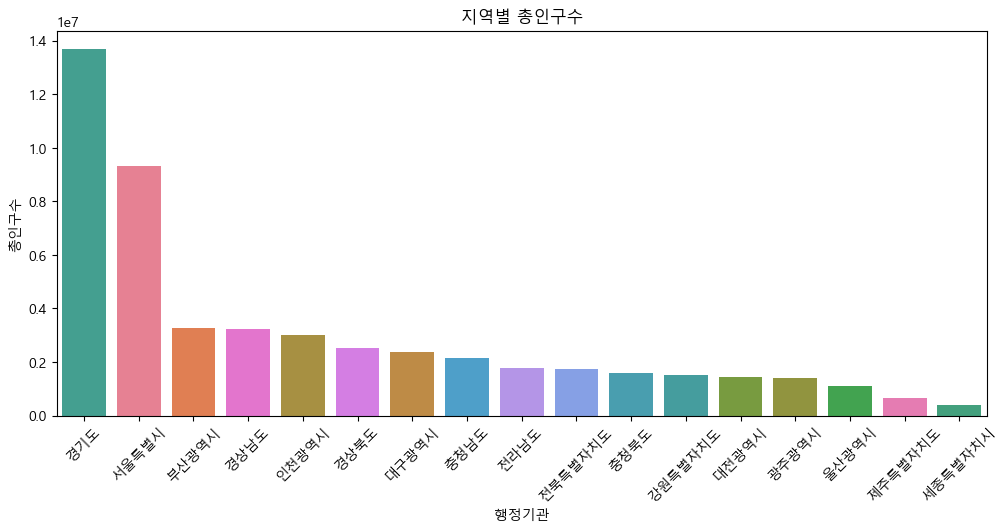

In [131]:
figure, axes1 = plt.subplots(nrows=1, ncols=1)
figure.set_size_inches(12, 5)

pop_plot = sns.barplot(x='행정기관', y='총인구수',\
    data=df,ax=axes1,hue='행정기관',order=order)
pop_plot.set_title(f'지역별 총인구수')

for item in axes1.get_xticklabels(): 
    item.set_rotation(45)
plt.show()


2. 세대당 인구수 높은 지역 TOP 5

In [132]:
df.loc[:,['행정기관', '세대당 인구']].sort_values('세대당 인구', ascending=False).head(5)\
    .reset_index(drop=True)

,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14


2-1. 지역별 세대당 인구 plot

In [133]:
order2 = df.sort_values('세대당 인구', ascending=False)['행정기관']

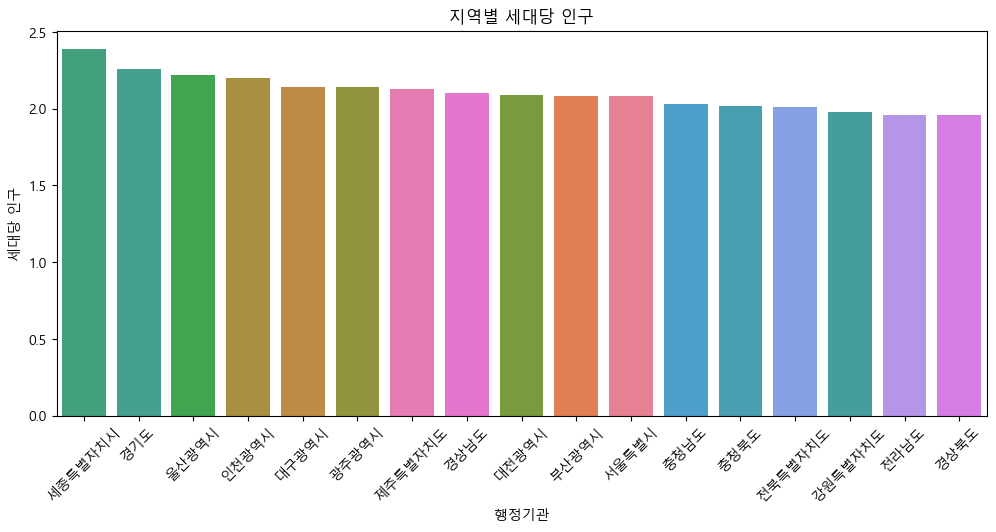

In [134]:
figure, axes1 = plt.subplots(nrows=1, ncols=1)
figure.set_size_inches(12, 5)

pop_plot = sns.barplot(x='행정기관', y='세대당 인구',\
    data=df,ax=axes1,hue='행정기관',order=order2)
pop_plot.set_title(f'지역별 세대당 인구')

for item in axes1.get_xticklabels(): 
    item.set_rotation(45)
plt.show()

3. 남녀 비율 분석

In [135]:
df.loc[:,['행정기관', '남여 비율']].sort_values('남여 비율', ascending=False)\
    .reset_index(drop=True)

,행정기관,남여 비율
0,울산광역시,1.06
1,충청남도,1.05
2,충청북도,1.04
3,경상남도,1.02
4,경상북도,1.02
5,전라남도,1.02
6,경기도,1.01
7,강원특별자치도,1.01
8,제주특별자치도,1.00
9,인천광역시,1.00


3-1. 남녀 비율 분석 plot

In [136]:
order3 = df.sort_values('남여 비율', ascending=False)['행정기관']

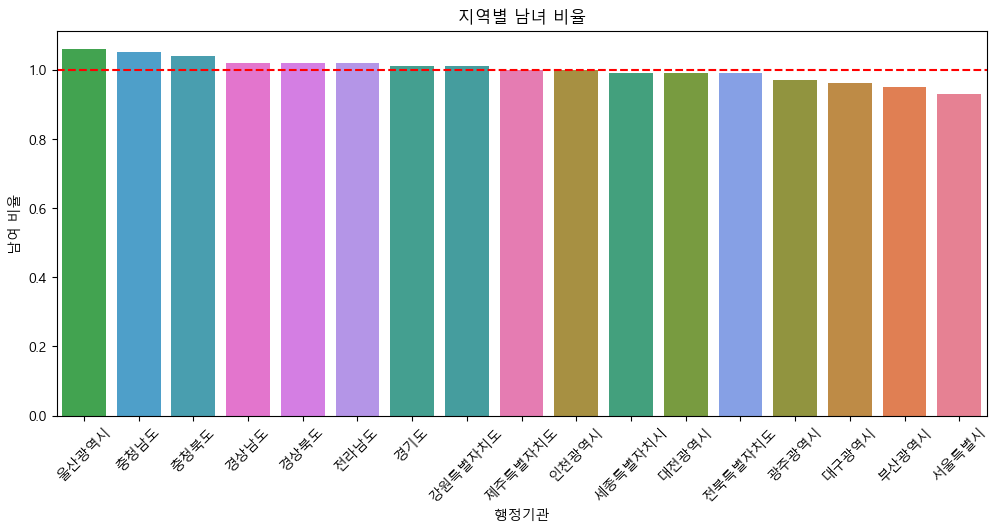

In [137]:
figure, axes1 = plt.subplots(nrows=1, ncols=1)
figure.set_size_inches(12, 5)

pop_plot = sns.barplot(x='행정기관', y='남여 비율',\
    data=df,ax=axes1,hue='행정기관',order=order3)
pop_plot.set_title(f'지역별 남녀 비율')

plt.axhline(y=1.0, color = 'red', linestyle='--')

for item in axes1.get_xticklabels(): 
    item.set_rotation(45)
plt.show()

4. 남자초과 / 여자초과 분석

In [138]:
def classification(val):
    if val > 1:
        return '남초'
    elif val < 1:
        return '여초'
    else:
        return '동일'

In [139]:
new_df = df.copy()
new_df['남초여초'] = new_df['남여 비율'].apply(classification)
ordered = new_df.loc[:,['행정기관','남여 비율','남초여초']]\
.reset_index(drop=True)

ordered.index = ordered.index + 1
ordered



,행정기관,남여 비율,남초여초
1,서울특별시,0.93,여초
2,부산광역시,0.95,여초
3,대구광역시,0.96,여초
4,인천광역시,1.00,동일
5,광주광역시,0.97,여초
6,대전광역시,0.99,여초
7,울산광역시,1.06,남초
8,세종특별자치시,0.99,여초
9,경기도,1.01,남초
10,강원특별자치도,1.01,남초


5. 세대당 인구 평균보다 높은 지역

In [140]:
new_df2 = df.copy()
mean_val = round(new_df2['세대당 인구'].mean(),2)
print(f'전국 평균 세대당 인구수: {mean_val}')

new_df2.loc[new_df2['세대당 인구'] > mean_val, ['행정기관', '세대당 인구']]\
    .sort_values('세대당 인구', ascending=False).reset_index(drop=True)

전국 평균 세대당 인구수: 2.11


,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14
5,광주광역시,2.14
6,제주특별자치도,2.13


5-1. 남초 vs 여초 개수 plot (seaborn의 countplot)  
          지역별 세대수 plot (seaborn의 barplot)

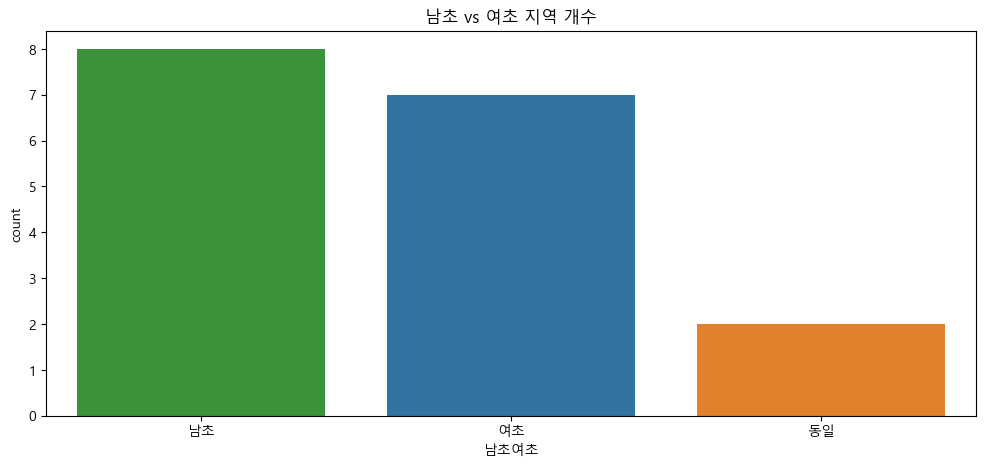

In [141]:
figure, axes1 = plt.subplots(nrows=1, ncols=1)
figure.set_size_inches(12,5)

plots = sns.countplot(data=new_df, x='남초여초', ax=axes1, 
    order=new_df['남초여초'].value_counts().index, hue='남초여초')

plots.set_title('남초 vs 여초 지역 개수')
plt.show()

In [142]:
order4 = new_df2.sort_values('세대수', ascending=False)['행정기관']

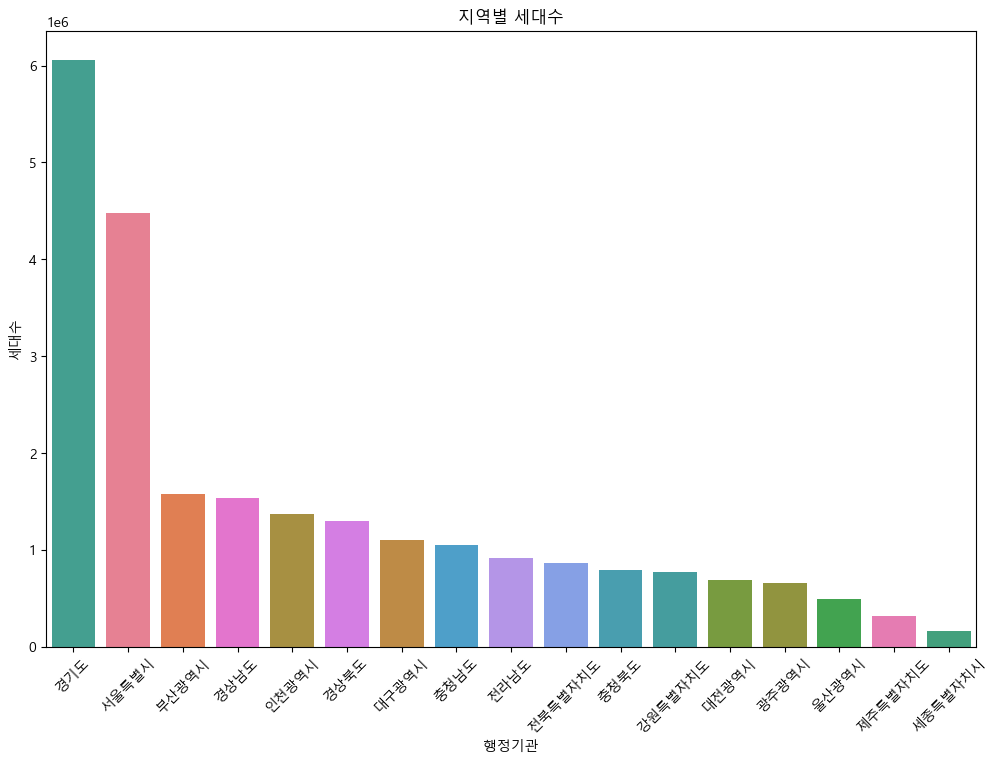

In [143]:
figure, axes1 = plt.subplots(nrows=1, ncols=1)
figure.set_size_inches(12, 8)

pop_plot = sns.barplot(x='행정기관', y='세대수',\
    data=new_df2,ax=axes1,hue='행정기관',order=order4)

pop_plot.set_title('지역별 세대수')

for item in axes1.get_xticklabels(): 
    item.set_rotation(45)

plt.show()